# Problem Statement:
FedEx handles millions of shipments daily across different regions, carriers, and time schedules.
Delays in shipment delivery can significantly affect customer satisfaction, operational costs, and network efficiency.

However, predicting these delays in advance is challenging due to the large number of influencing factors such as route distance, carrier performance, time of day, and day of the week.

# Objective:
To build a predictive model that accurately determines whether a shipment will be delivered on time or delayed, based on historical shipment data.

# Solution Provided:
A predictive modeling approach was implemented using Logistic Regression and Random Forest Classifier to identify the key factors influencing shipment delays. Based on the model insights, delays can be reduced by optimizing shipment scheduling, improving route planning for long-distance deliveries, and proactively managing high-risk shipments. The predictive model can also be used to flag potential delays in advance, enabling timely interventions to improve on-time delivery performance.

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Loading the Dataset
df = pd.read_csv(r"C:\Users\User\Desktop\fedex.csv")

In [3]:
df.head(10)

,Year,Month,DayofMonth,DayOfWeek,Actual_Shipment_Time,Planned_Shipment_Time,Planned_Delivery_Time,Carrier_Name,Carrier_Num,Planned_TimeofTravel,Shipment_Delay,Source,Destination,Distance,Delivery_Status
0,2008,1,3,4,2003.0,1955,2225,WN,335,150.0,8.0,IAD,TPA,810,0.0
1,2008,1,3,4,754.0,735,1000,WN,3231,145.0,19.0,IAD,TPA,810,1.0
2,2008,1,3,4,628.0,620,750,WN,448,90.0,8.0,IND,BWI,515,0.0
3,2008,1,3,4,926.0,930,1100,WN,1746,90.0,-4.0,IND,BWI,515,0.0
4,2008,1,3,4,1829.0,1755,1925,WN,3920,90.0,34.0,IND,BWI,515,1.0
5,2008,1,3,4,1940.0,1915,2110,WN,378,115.0,25.0,IND,JAX,688,1.0
6,2008,1,3,4,1937.0,1830,1940,WN,509,250.0,67.0,IND,LAS,1591,1.0
7,2008,1,3,4,1039.0,1040,1150,WN,535,250.0,-1.0,IND,LAS,1591,0.0
8,2008,1,3,4,617.0,615,650,WN,11,95.0,2.0,IND,MCI,451,0.0
9,2008,1,3,4,1620.0,1620,1655,WN,810,95.0,0.0,IND,MCI,451,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3604175 entries, 0 to 3604174
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Year                   int64  
 1   Month                  int64  
 2   DayofMonth             int64  
 3   DayOfWeek              int64  
 4   Actual_Shipment_Time   float64
 5   Planned_Shipment_Time  int64  
 6   Planned_Delivery_Time  int64  
 7   Carrier_Name           object 
 8   Carrier_Num            int64  
 9   Planned_TimeofTravel   float64
 10  Shipment_Delay         float64
 11  Source                 object 
 12  Destination            object 
 13  Distance               int64  
 14  Delivery_Status        float64
dtypes: float64(4), int64(8), object(3)
memory usage: 412.5+ MB


In [5]:
df.describe()

,Year,Month,DayofMonth,DayOfWeek,Actual_Shipment_Time,Planned_Shipment_Time,Planned_Delivery_Time,Carrier_Num,Planned_TimeofTravel,Shipment_Delay,Distance,Delivery_Status
count,3604175.0,3.604175e+06,3.604175e+06,3.604175e+06,3.522573e+06,3.604175e+06,3.604175e+06,3.604175e+06,3.603628e+06,3.522573e+06,3.604175e+06,3.522573e+06
mean,2008.0,3.514942e+00,1.568481e+01,3.934604e+00,1.338455e+03,1.329371e+03,1.495305e+03,2.223795e+03,1.291603e+02,1.115893e+01,7.280915e+02,2.038890e-01
std,0.0,1.709912e+00,8.763332e+00,1.987126e+00,4.814053e+02,4.664365e+02,4.854825e+02,1.944583e+03,6.951011e+01,3.618888e+01,5.611318e+02,4.028875e-01
min,2008.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-2.500000e+01,-9.200000e+01,1.100000e+01,0.000000e+00
25%,2008.0,2.000000e+00,8.000000e+00,2.000000e+00,9.290000e+02,9.250000e+02,1.115000e+03,6.160000e+02,8.000000e+01,-4.000000e+00,3.250000e+02,0.000000e+00
50%,2008.0,4.000000e+00,1.600000e+01,4.000000e+00,1.329000e+03,1.321000e+03,1.519000e+03,1.573000e+03,1.110000e+02,-1.000000e+00,5.830000e+02,0.000000e+00
75%,2008.0,5.000000e+00,2.300000e+01,6.000000e+00,1.733000e+03,1.720000e+03,1.910000e+03,3.602000e+03,1.600000e+02,1.000000e+01,9.570000e+02,0.000000e+00
max,2008.0,6.000000e+00,3.100000e+01,7.000000e+00,2.400000e+03,2.359000e+03,2.400000e+03,9.741000e+03,1.435000e+03,2.467000e+03,4.962000e+03,1.000000e+00


In [6]:
# Checking null values
df.isnull().sum()

Year                         0
Month                        0
DayofMonth                   0
DayOfWeek                    0
Actual_Shipment_Time     81602
Planned_Shipment_Time        0
Planned_Delivery_Time        0
Carrier_Name                 0
Carrier_Num                  0
Planned_TimeofTravel       547
Shipment_Delay           81602
Source                       0
Destination                  0
Distance                     0
Delivery_Status          81602
dtype: int64

In [7]:
# Calculating null value percentage
(df.isnull().sum()/len(df))*100

Year                     0.000000
Month                    0.000000
DayofMonth               0.000000
DayOfWeek                0.000000
Actual_Shipment_Time     2.264096
Planned_Shipment_Time    0.000000
Planned_Delivery_Time    0.000000
Carrier_Name             0.000000
Carrier_Num              0.000000
Planned_TimeofTravel     0.015177
Shipment_Delay           2.264096
Source                   0.000000
Destination              0.000000
Distance                 0.000000
Delivery_Status          2.264096
dtype: float64

In [8]:
# Checking "Planned_TimeofTravel" column for values less than 0.
df[df["Planned_TimeofTravel"]<=0]

,Year,Month,DayofMonth,DayOfWeek,Actual_Shipment_Time,Planned_Shipment_Time,Planned_Delivery_Time,Carrier_Name,Carrier_Num,Planned_TimeofTravel,Shipment_Delay,Source,Destination,Distance,Delivery_Status
768964,2008,2,3,7,1747.0,1638,1729,OO,6004,-9.0,69.0,ORD,IND,177,1.0
1358057,2008,3,8,6,1839.0,1756,1735,OO,5428,-21.0,43.0,MRY,SFO,77,1.0
1992427,2008,4,11,5,725.0,710,645,OO,2631,-25.0,15.0,MKG,MKE,85,0.0
1992500,2008,4,11,5,610.0,600,648,OO,2780,-12.0,10.0,CWA,MKE,154,0.0
3171278,2008,6,5,4,634.0,600,650,OO,2780,-10.0,34.0,CWA,MKE,154,1.0
3171282,2008,6,5,4,644.0,600,642,OO,2791,-18.0,44.0,GRB,MKE,107,1.0


In [9]:
# Removing rows which has Planned_TimeofTravel less than 0.
df=df[df["Planned_TimeofTravel"]>0]

In [10]:
# Checking for null values
df.isnull().sum()

Year                         0
Month                        0
DayofMonth                   0
DayOfWeek                    0
Actual_Shipment_Time     81461
Planned_Shipment_Time        0
Planned_Delivery_Time        0
Carrier_Name                 0
Carrier_Num                  0
Planned_TimeofTravel         0
Shipment_Delay           81461
Source                       0
Destination                  0
Distance                     0
Delivery_Status          81461
dtype: int64

In [11]:
# Dropping null values
df.dropna(inplace=True)

In [12]:
# Checking for null values
df.isnull().sum()

Year                     0
Month                    0
DayofMonth               0
DayOfWeek                0
Actual_Shipment_Time     0
Planned_Shipment_Time    0
Planned_Delivery_Time    0
Carrier_Name             0
Carrier_Num              0
Planned_TimeofTravel     0
Shipment_Delay           0
Source                   0
Destination              0
Distance                 0
Delivery_Status          0
dtype: int64

In [13]:
# Converting time columns to datetime.time format
time_columns = ["Actual_Shipment_Time","Planned_Shipment_Time","Planned_Delivery_Time"]

for col in time_columns:
    df[col] = df[col].apply(lambda x: f"{int(x):04}" if pd.notnull(x) else np.nan)
    df[col] = pd.to_datetime(df[col], format="%H%M", errors="coerce")
    df[col] = df[col].dt.time

In [14]:
df

,Year,Month,DayofMonth,DayOfWeek,Actual_Shipment_Time,Planned_Shipment_Time,Planned_Delivery_Time,Carrier_Name,Carrier_Num,Planned_TimeofTravel,Shipment_Delay,Source,Destination,Distance,Delivery_Status
0,2008,1,3,4,20:03:00,19:55:00,22:25:00,WN,335,150.0,8.0,IAD,TPA,810,0.0
1,2008,1,3,4,07:54:00,07:35:00,10:00:00,WN,3231,145.0,19.0,IAD,TPA,810,1.0
2,2008,1,3,4,06:28:00,06:20:00,07:50:00,WN,448,90.0,8.0,IND,BWI,515,0.0
3,2008,1,3,4,09:26:00,09:30:00,11:00:00,WN,1746,90.0,-4.0,IND,BWI,515,0.0
4,2008,1,3,4,18:29:00,17:55:00,19:25:00,WN,3920,90.0,34.0,IND,BWI,515,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3604170,2008,6,19,4,10:59:00,11:00:00,12:56:00,DL,1547,236.0,-1.0,ATL,JAC,1572,0.0
3604171,2008,6,19,4,05:55:00,06:00:00,07:38:00,DL,1548,98.0,-5.0,RSW,ATL,515,0.0
3604172,2008,6,19,4,08:21:00,08:27:00,10:03:00,DL,1548,96.0,-6.0,ATL,IND,432,0.0
3604173,2008,6,19,4,07:18:00,07:35:00,08:52:00,DL,1551,77.0,-17.0,CAE,ATL,191,0.0


# Exploratory Data Analysis

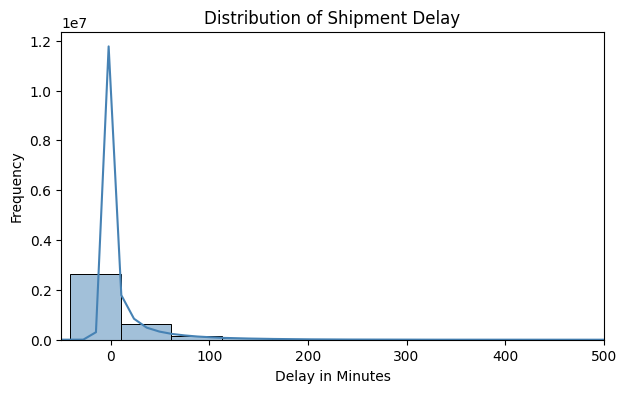

In [15]:
# Distribution of Shipment Delay

plt.figure(figsize=(7,4))
sns.histplot(df["Shipment_Delay"], kde=True, bins=50, color="steelblue")
plt.title("Distribution of Shipment Delay")
plt.xlim(-50,500)
plt.xlabel("Delay in Minutes")
plt.ylabel("Frequency")
plt.show()

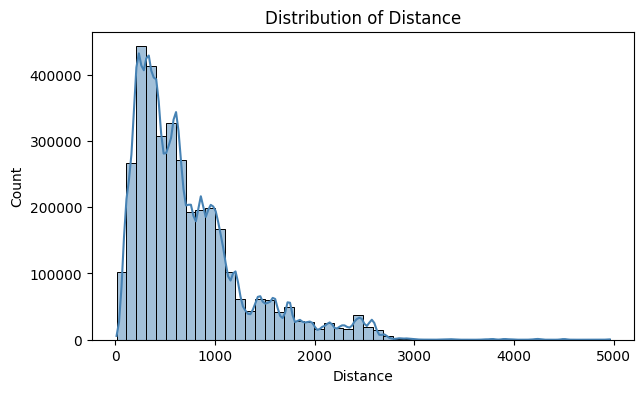

In [16]:
# Distribution of Distance

plt.figure(figsize=(7,4))
sns.histplot(df['Distance'], kde=True, bins=50, color="steelblue")
plt.title("Distribution of Distance")
plt.show()

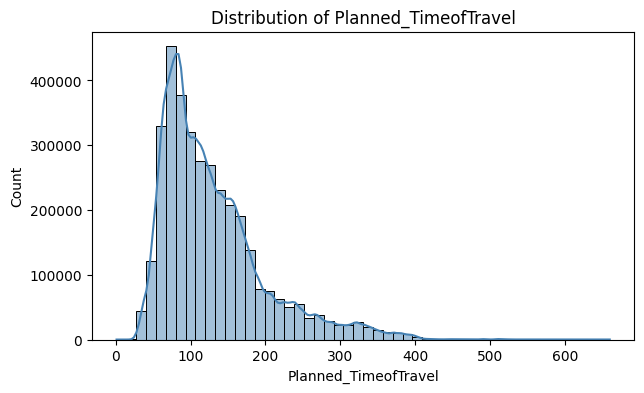

In [17]:
# Distribution of Planned_TimeofTravel

plt.figure(figsize=(7,4))
sns.histplot(df['Planned_TimeofTravel'], kde=True, bins=50, color="steelblue")
plt.title("Distribution of Planned_TimeofTravel")
plt.show()

In [18]:
# Checking the skewness value
df[['Distance', 'Shipment_Delay', 'Planned_TimeofTravel']].skew()

Distance                1.622146
Shipment_Delay          6.257134
Planned_TimeofTravel    1.493569
dtype: float64

# Handling Skewness

Continuous features such as Distance, Shipment_Delay, and Planned_TimeofTravel were positively skewed. To normalize their distributions, a log transformation (np.log1p) was applied. This improved feature symmetry, reduced outlier impact, and enhanced the Logistic Regression model’s accuracy and stability.

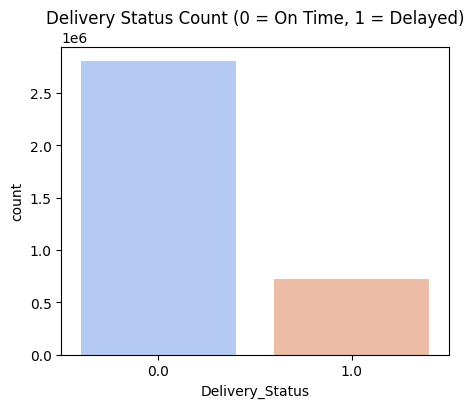

In [19]:
# Delivery Status Count

plt.figure(figsize=(5,4))
sns.countplot(x="Delivery_Status", data=df, palette="coolwarm")
plt.title("Delivery Status Count (0 = On Time, 1 = Delayed)")
plt.show()

# Handling Imbalanced Target Variable

The target column (Delivery_Status) was found to be imbalanced, with a much higher number of on-time deliveries compared to delayed shipments. 
To address this, the SMOTE (Synthetic Minority Oversampling Technique) was applied. 
SMOTE generates synthetic samples for the minority class by interpolating between existing instances, ensuring a more balanced class distribution. 
This helped prevent model bias toward the majority class and improved the Logistic Regression model’s ability to accurately predict both on-time and delayed shipments.

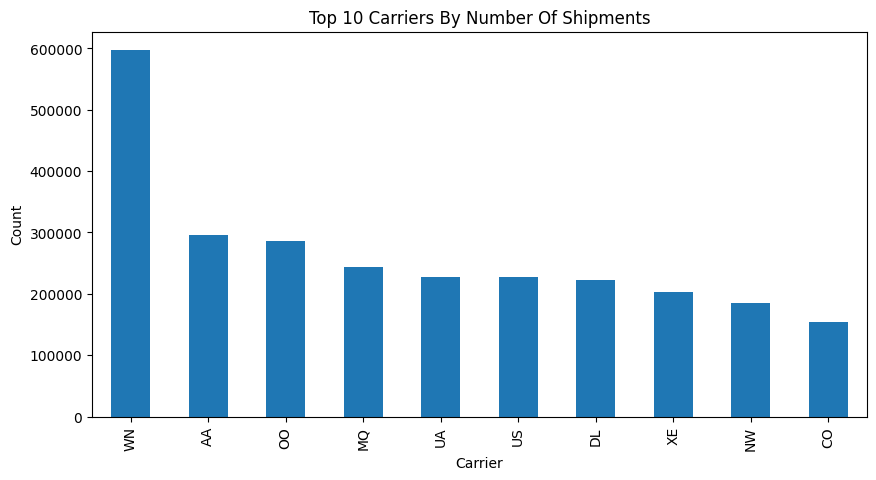

In [20]:
# Most Frequent Carriers

plt.figure(figsize=(10,5))
df["Carrier_Name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Carriers By Number Of Shipments")
plt.xlabel("Carrier")
plt.ylabel("Count")
plt.show()

# Top 10 Carriers by Shipments

The leading carriers are WN (Southwest Airlines), AA (American Airlines), OO (SkyWest), and MQ (Envoy Air).
These carriers handle the majority of shipments, making their performance crucial for improving delivery efficiency.

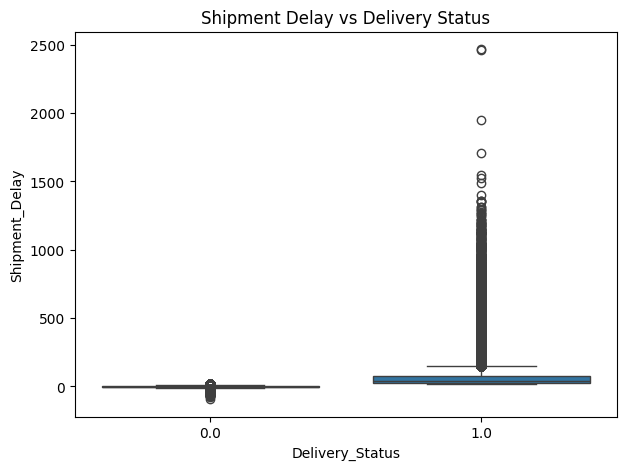

In [21]:
# Shipment Delay vs Delivery Status

plt.figure(figsize=(7,5))
sns.boxplot(x="Delivery_Status", y="Shipment_Delay", data=df)
plt.title("Shipment Delay vs Delivery Status")
plt.show()

# Handling Outliers

During data preprocessing, the Shipment_Delay feature showed the presence of extreme values, indicating a few shipments with unusually long delays. To reduce their impact, a log transformation (np.log1p) was applied, which minimized outlier influence and improved model stability.

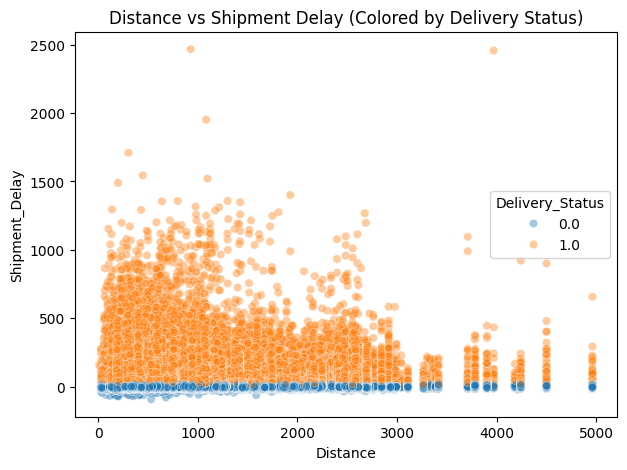

In [22]:
# Distance vs Shipment Delay

plt.figure(figsize=(7,5))
sns.scatterplot(x='Distance', y='Shipment_Delay', hue='Delivery_Status', data=df, alpha=0.4)
plt.title("Distance vs Shipment Delay (Colored by Delivery Status)")
plt.show()

# Distance vs Shipment Delay

Longer shipment distances show greater delay variability.
Most delayed shipments occur over medium to long distances, highlighting distance as a key factor affecting delivery performance.

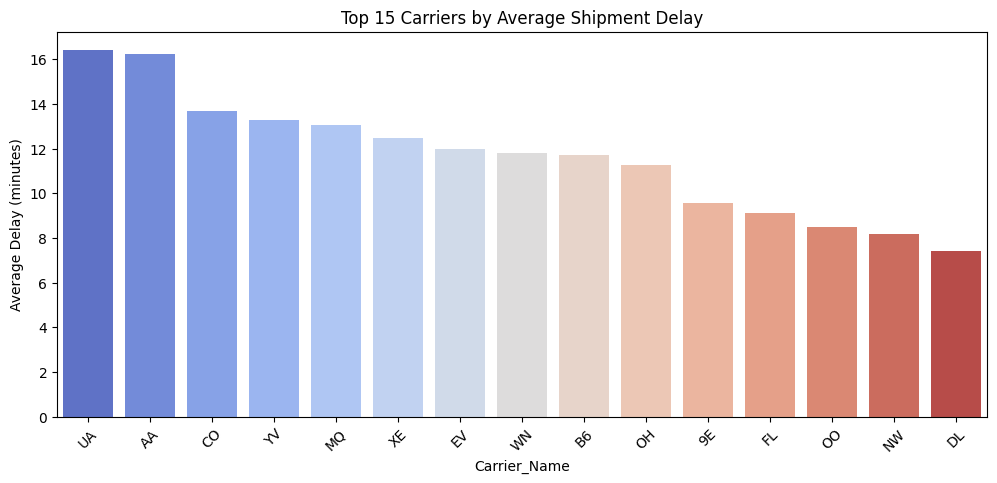

In [23]:
# Carrier vs Average Delay

plt.figure(figsize=(12,5))
carrier_delay = df.groupby('Carrier_Name')['Shipment_Delay'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 15 Carriers by Average Shipment Delay")
plt.ylabel("Average Delay (minutes)")
plt.show()

# Top 15 Carriers by Average Shipment Delay

The graph highlights that carriers UA (United Airlines) and AA (American Airlines) experience the highest average shipment delays, while DL (Delta Airlines) and NW (Northwest Airlines) show the lowest. This indicates variations in carrier efficiency and reliability, suggesting that improving scheduling, operations, or coordination with high-delay carriers can enhance overall delivery performance.

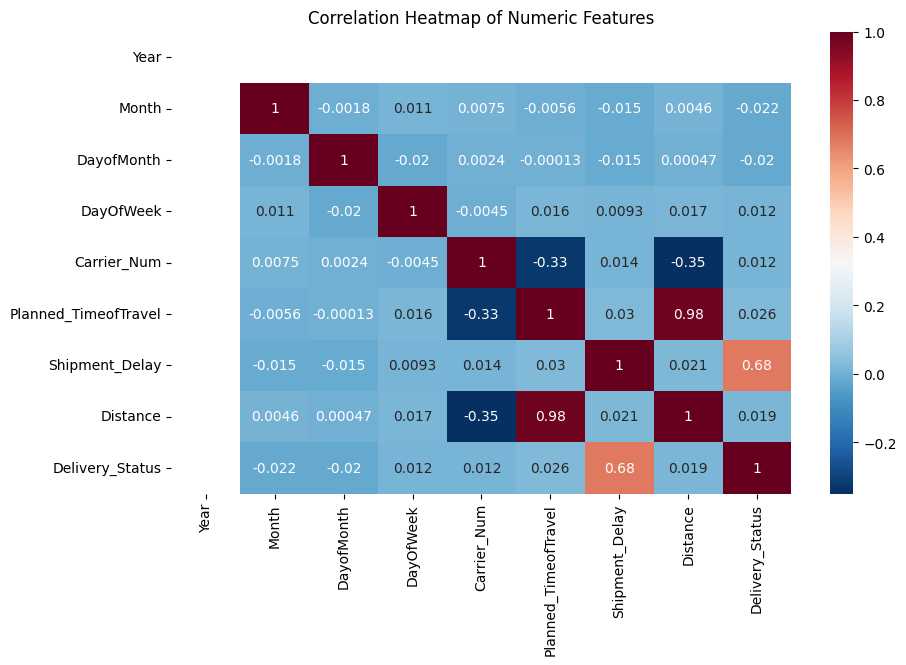

In [24]:
# Correlation Analysis

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Correlation Heatmap of Numeric Features

The correlation heatmap shows a strong positive correlation between Planned_TimeofTravel and Distance (0.98), indicating that longer distances require more planned travel time. A moderate positive correlation is also observed between Shipment_Delay and Delivery_Status (0.68), confirming that higher delays are strongly linked to late deliveries. Other features show weak correlations, suggesting limited linear relationships among them.

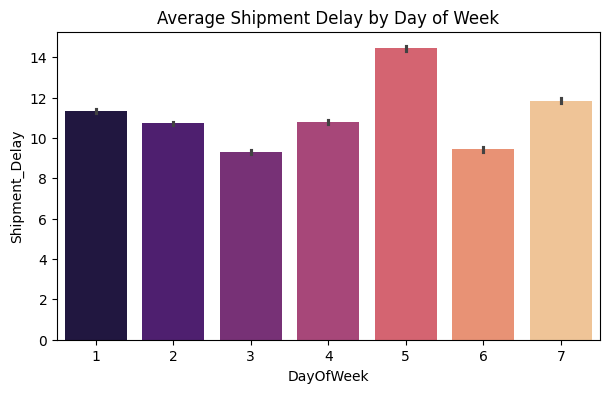

In [25]:
# Average delay by day of week

plt.figure(figsize=(7,4))
sns.barplot(x='DayOfWeek', y='Shipment_Delay', data=df, palette='magma')
plt.title("Average Shipment Delay by Day of Week")
plt.show()

# Average Shipment Delay by Day of Week

The graph shows that Day 5 (Friday) experiences the highest average shipment delays, while Day 3 (Wednesday) and Day 6 (Saturday) have the lowest. This pattern suggests that end-of-week operations may face higher load or scheduling inefficiencies, highlighting an opportunity to optimize resource allocation and shipment planning around Fridays.

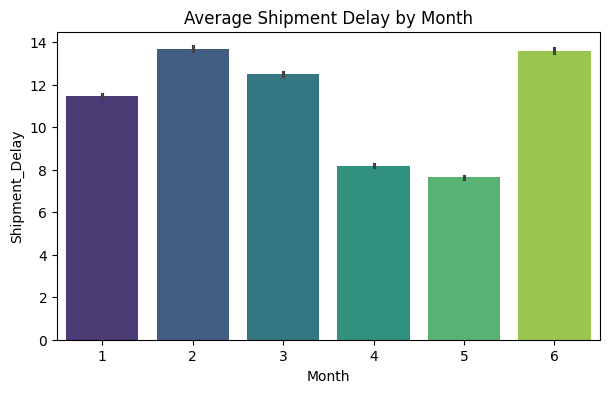

In [26]:
# Average delay by month

plt.figure(figsize=(7,4))
sns.barplot(x='Month', y='Shipment_Delay', data=df, palette='viridis')
plt.title("Average Shipment Delay by Month")
plt.show()

# Average Shipment Delay by Month

The graph indicates that February (Month 2) and June (Month 6) have the highest average shipment delays, while April (Month 4) and May (Month 5) experience the lowest. This suggests possible seasonal or operational impacts during early and mid-year months, highlighting periods where improved planning and resource allocation could reduce delays.

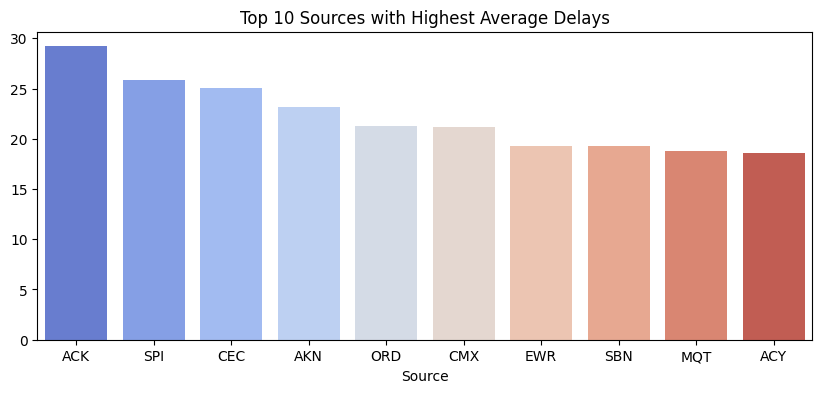

In [27]:
# Average delay by source (top 10)

top_source_delay = df.groupby('Source')['Shipment_Delay'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_source_delay.index, y=top_source_delay.values, palette='coolwarm')
plt.title("Top 10 Sources with Highest Average Delays")
plt.show()

# Top 10 Sources with Highest Average Delays

The graph indicates that ACK (Nantucket Memorial Airport) and SPI (Abraham Lincoln Capital Airport) experience the highest average shipment delays among all sources, followed by CEC (Del Norte County Regional Airport) and AKN (King Salmon Airport). This suggests possible congestion, weather issues, or logistical inefficiencies at these locations. While sources like MQT (Sawyer International Airport) and ACY (Atlantic City International Airport) show relatively lower delays, there is still scope for operational improvements.

# Machine Learning Model

In [28]:
# Applying Log Transformation to handle skewness and outliers

df["Shipment_Delay_log"] = np.log1p(df["Shipment_Delay"] - df["Shipment_Delay"].min() + 1)
df["Distance_log"] = np.log1p(df["Distance"])
df["Planned_TimeofTravel_log"] = np.log1p(df["Planned_TimeofTravel"])

In [29]:
# Checking Skewness value

df[['Distance_log', 'Shipment_Delay_log', 'Planned_TimeofTravel_log']].skew()

Distance_log               -0.191091
Shipment_Delay_log          2.700272
Planned_TimeofTravel_log    0.207220
dtype: float64

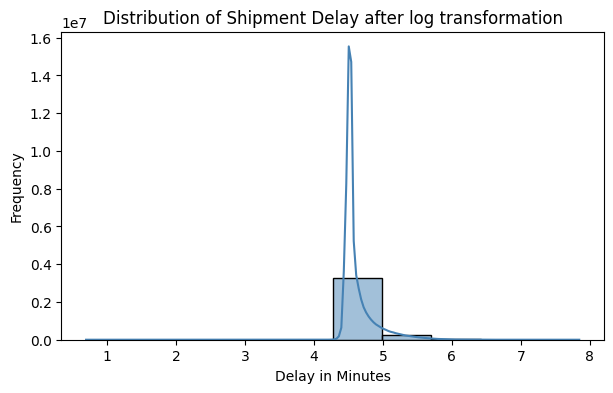

In [30]:
# Distribution of Shipment Delay after log transformation

plt.figure(figsize=(7,4))
sns.histplot(df["Shipment_Delay_log"], kde=True, bins=10, color="steelblue")
plt.title("Distribution of Shipment Delay after log transformation")
plt.xlabel("Delay in Minutes")
plt.ylabel("Frequency")
plt.show()

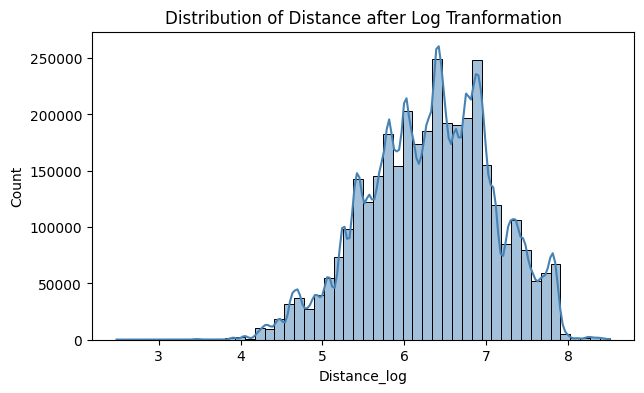

In [31]:
# Distribution of Distance after Log Transformation

plt.figure(figsize=(7,4))
sns.histplot(df['Distance_log'], kde=True, bins=50, color="steelblue")
plt.title("Distribution of Distance after Log Tranformation")
plt.show()

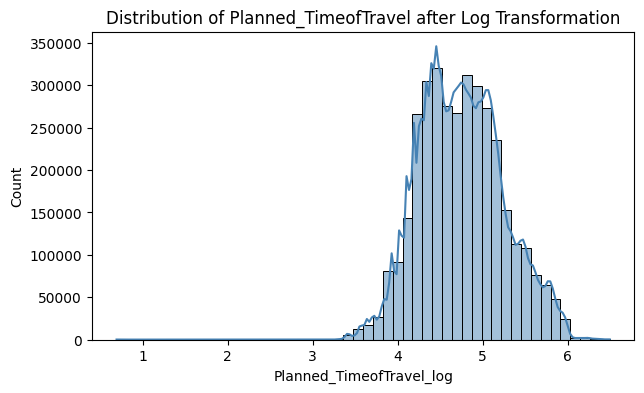

In [32]:
# Distribution of Planned_TimeofTravel after Log Transformation

plt.figure(figsize=(7,4))
sns.histplot(df['Planned_TimeofTravel_log'], kde=True, bins=50, color="steelblue")
plt.title("Distribution of Planned_TimeofTravel after Log Transformation")
plt.show()

# Feature Skewness After Log Transformation

After applying logarithmic transformations to continuous variables, the following skewness values were obtained:

Distance_log: -0.19 (approximately symmetric)

Shipment_Delay_log: 2.70 (moderately right-skewed)

Planned_TimeofTravel_log: 0.21 (approximately symmetric)

The transformations significantly reduced skewness for most features. Although Shipment_Delay_log remains moderately skewed, it was retained in its transformed form since it effectively reduces the impact of extreme delay values without distorting the data’s underlying distribution.

In [33]:
# Encoding Categorical Variables

cat_cols = ["Carrier_Name", "Source", "Destination"]

le = LabelEncoder()
for cols in cat_cols:
    df[cols] = le.fit_transform(df[cols])

In [34]:
# Defining Feature(X) and Target(y)

X = df.drop(["Delivery_Status","Actual_Shipment_Time","Planned_Shipment_Time","Planned_Delivery_Time","Shipment_Delay","Distance","Planned_TimeofTravel","Shipment_Delay_log"], axis=1)
y = df["Delivery_Status"]

In [35]:
X

,Year,Month,DayofMonth,DayOfWeek,Carrier_Name,Carrier_Num,Source,Destination,Distance_log,Planned_TimeofTravel_log
0,2008,1,3,4,17,335,134,281,6.698268,5.017280
1,2008,1,3,4,17,3231,134,281,6.698268,4.983607
2,2008,1,3,4,17,448,139,48,6.246107,4.510860
3,2008,1,3,4,17,1746,139,48,6.246107,4.510860
4,2008,1,3,4,17,3920,139,48,6.246107,4.510860
...,...,...,...,...,...,...,...,...,...,...
3604170,2008,6,19,4,6,1547,18,146,7.360740,5.468060
3604171,2008,6,19,4,6,1548,242,18,6.246107,4.595120
3604172,2008,6,19,4,6,1548,18,140,6.070738,4.574711
3604173,2008,6,19,4,6,1551,50,18,5.257495,4.356709


In [36]:
y

0          0.0
1          1.0
2          0.0
3          0.0
4          1.0
          ... 
3604170    0.0
3604171    0.0
3604172    0.0
3604173    0.0
3604174    1.0
Name: Delivery_Status, Length: 3522161, dtype: float64

In [37]:
# Spliting the Data(80% training data and 20% testing)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Applying SMOTE to the training set (not test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [39]:
# Checking values before vs after SMOTE Technique
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Delivery_Status
0.0    2243082
1.0     574646
Name: count, dtype: int64
After SMOTE: Delivery_Status
0.0    2243082
1.0    2243082
Name: count, dtype: int64


# Balancing Target Variable

The target variable was imbalanced.
After applying SMOTE, synthetic samples were generated, resulting in a balanced dataset and improved model performance.

# 1. Logistic Regression

In [40]:
# Building and Training Logistic Regression Model

model = LogisticRegression()
model.fit(X_train_res,y_train_res)

LogisticRegression()

In [41]:
# Make Predictions
y_pred = model.predict(X_test)

Accuracy: 0.5297963042617254
              precision    recall  f1-score   support

         0.0       0.80      0.55      0.65    560989
         1.0       0.21      0.47      0.29    143444

    accuracy                           0.53    704433
   macro avg       0.50      0.51      0.47    704433
weighted avg       0.68      0.53      0.58    704433



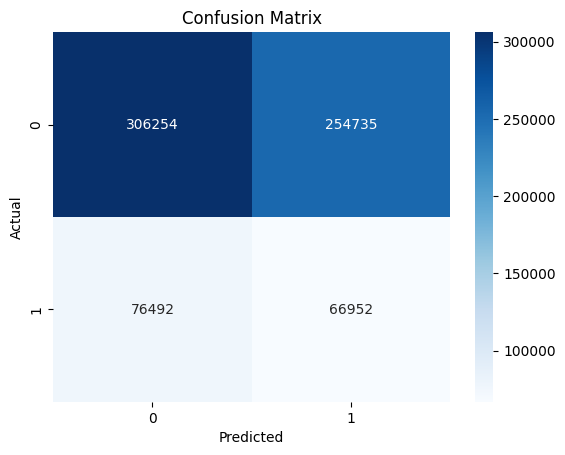

In [42]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
# Checking Training and Testing Accuracy

train_pred = model.predict(X_train_res)

train_acc = accuracy_score(y_train_res, train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.5526193424939436
Testing Accuracy: 0.5297963042617254


# Model Selection

Logistic Regression was underfitting the data. To improve accuracy, Random Forest was used as it captures complex, non-linear relationships more effectively.

# 2. Random Forest Classifier

In [44]:
X_rf = df.drop(["Delivery_Status","Actual_Shipment_Time","Planned_Shipment_Time","Planned_Delivery_Time","Shipment_Delay_log","Distance_log","Planned_TimeofTravel_log","Shipment_Delay"], axis=1)
y_rf = df["Delivery_Status"]

In [45]:
X_rf

,Year,Month,DayofMonth,DayOfWeek,Carrier_Name,Carrier_Num,Planned_TimeofTravel,Source,Destination,Distance
0,2008,1,3,4,17,335,150.0,134,281,810
1,2008,1,3,4,17,3231,145.0,134,281,810
2,2008,1,3,4,17,448,90.0,139,48,515
3,2008,1,3,4,17,1746,90.0,139,48,515
4,2008,1,3,4,17,3920,90.0,139,48,515
...,...,...,...,...,...,...,...,...,...,...
3604170,2008,6,19,4,6,1547,236.0,18,146,1572
3604171,2008,6,19,4,6,1548,98.0,242,18,515
3604172,2008,6,19,4,6,1548,96.0,18,140,432
3604173,2008,6,19,4,6,1551,77.0,50,18,191


In [46]:
y_rf

0          0.0
1          1.0
2          0.0
3          0.0
4          1.0
          ... 
3604170    0.0
3604171    0.0
3604172    0.0
3604173    0.0
3604174    1.0
Name: Delivery_Status, Length: 3522161, dtype: float64

In [47]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

In [49]:
# Initialize RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=3, random_state=42)

# Training the model
model_rf.fit(X_train_rf,y_train_rf)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, random_state=42)

In [50]:
# Making predictions
y_pred_rf = model_rf.predict(X_test_rf)

Accuracy: 0.7964377023790765
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89    560989
         1.0       0.86      0.00      0.00    143444

    accuracy                           0.80    704433
   macro avg       0.83      0.50      0.44    704433
weighted avg       0.81      0.80      0.71    704433



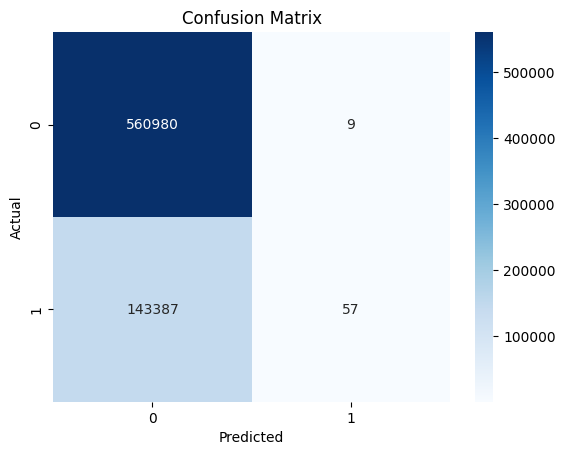

In [51]:
# Accuracy
print("Accuracy:", accuracy_score(y_test_rf, y_pred_rf))

# Classification report
print(classification_report(y_test_rf, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test_rf, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
# Checking Training and Testing Accuracy

train_pred_rf = model_rf.predict(X_train_rf)

train_acc_rf = accuracy_score(y_train_rf, train_pred_rf)
test_acc_rf = accuracy_score(y_test_rf, y_pred_rf)

print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy:", test_acc_rf)

Training Accuracy: 0.7961378813001113
Testing Accuracy: 0.7964377023790765


# Conclusion

The analysis successfully identified the major factors contributing to shipment delays using Logistic Regression and Random Forest Classifier. Logistic Regression showed underfitting due to the dataset’s non-linear relationships, while Random Forest achieved higher accuracy and better generalization. By addressing imbalanced data with SMOTE and applying necessary data transformations, the predictive model can effectively forecast potential delays. These insights can help optimize shipment planning, enhance route efficiency, and ultimately improve on-time delivery performance.